# Build an `InSituData` object from custom data

This notebook demonstrates how to build an `InSituData` object from scratch using dummy data. This hopefully helps to understand how to load custom data into the framework. Since every technology has different output files, the way how to load the data into the right format can vary between technologies. If you have problems with this, please write an issue and we will try to help you with it.

In [1]:
## The following code ensures that all functions and init files are reloaded before executions.
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import string
from pathlib import Path
from typing import Literal
from uuid import uuid4

import anndata as ad
import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Polygon

from insitupy import InSituData
from insitupy.containers import (
    BoundariesData,
    CellData,
)

## Let's start by generating main modalities and adding them into InSituData

Below you can find all functions used to generate the dummy code

In [3]:
# Function to generate a random H&E-like image
def generate_random_he_image(width, height):
    # Hematoxylin (blue-purple) and Eosin (pink) color ranges
    hematoxylin_color = np.array([102, 51, 153], dtype=np.uint8)  # Scaled to 0-255 range
    eosin_color = np.array([255, 204, 204], dtype=np.uint8)  # Scaled to 0-255 range
    # hematoxylin_color = np.array([0.4, 0.2, 0.6])
    # eosin_color = np.array([1.0, 0.8, 0.8])

    # random_image = np.random.rand(width, height, 3)
    random_image = np.random.randint(0, 256, (width, height, 3), dtype=np.uint8)
    he_image = random_image * hematoxylin_color // 255 + (255 - random_image) * eosin_color // 255
    # he_image = random_image * hematoxylin_color + (1 - random_image) * eosin_color

    return he_image

# Function to generate a random grayscale DAPI-like image
def generate_random_dapi_image(width, height):
    # DAPI (blue) color range in grayscale
    dapi_color = np.array([0.1, 0.1, 0.8])

    random_image = np.random.rand(width, height)
    dapi_image = random_image * dapi_color[2]  # Use the blue channel for grayscale

    return dapi_image

def generate_random_gene_names(length):
    letters = string.ascii_uppercase
    random_order = ''.join(random.choices(letters, k=length))
    return random_order

def generate_dummy_anndata(
    width,
    height,
    n_cells,
    num_genes = 400,
    pixel_size = 0.2125
    ):
    # In the next step we generate an `AnnData` object with respective spatial coordinates and a `Dask` Array with cellular boundaries for the respective cells.
    pixel_coordinates = np.random.rand(n_cells, 2) * [width, height]

    # Convert pixel coordinates to micrometers (1 pixel = 0.2125 micrometers)
    micrometer_coordinates = pixel_coordinates * pixel_size

    # Generate random gene expression counts matrix (n_cells x num_genes)
    gene_counts = np.random.poisson(lam=5, size=(n_cells, num_genes))

    # Create an AnnData object with gene expression counts and spatial coordinates
    adata = ad.AnnData(X=gene_counts)
    adata.obsm['spatial'] = micrometer_coordinates
    # Example observations (metadata)
    obs_data = {
        'cell_type': ['type1', 'type2'] * (n_cells // 2),  # Example cell types
        'batch': ['batch1'] * (n_cells // 2) + ['batch2'] * (n_cells // 2)  # Example batch information
    }

    # Add observations to the obs attribute
    adata.obs = adata.obs.assign(**obs_data)

    # add cell names
    adata.obs_names = [str(elem) for elem in range(1, n_cells+1)]

    # add gene names
    adata.var_names = [generate_random_gene_names(length=5) for _ in range(len(adata.var_names))]
    return adata

def generate_cellular_boundaries_array(width, height, cell_positions, pixel_size, cell_size):
    # Create an empty mask
    mask = np.zeros((height, width), dtype=np.uint8)

    # Create random roundish shapes
    seg_mask_value = []
    for i, (x, y) in enumerate(cell_positions/pixel_size):
        num_points = np.random.randint(5, 15)  # Random number of points
        points = np.random.randint(-cell_size, cell_size, (num_points, 2)) + [x, y]
        hull = cv2.convexHull(points.astype(np.int32))
        value = i+1
        cv2.fillConvexPoly(mask, hull, value)
        seg_mask_value.append(value)

    # Convert the NumPy array to a Dask array with chunks
    #dask_array = da.from_array(mask, chunks=(50, 50))

    #return dask_array, seg_mask_value
    return mask, seg_mask_value

# Function to generate random polygons
def generate_random_geometries(num_polygons, x_size, y_size, pixel_size, mode: Literal["region", "annotation"]):
    polygons = []
    attempts = 0
    max_attempts = num_polygons * 10  # Limit the number of attempts to avoid infinite loop

    while len(polygons) < num_polygons and attempts < max_attempts:
        # Generate random center point
        center_x = np.random.uniform(0, x_size*pixel_size)
        center_y = np.random.uniform(0, y_size*pixel_size)

        # Generate random size for the polygon
        size = np.random.uniform(10, 20)

        # Create a square polygon around the center point
        polygon = Polygon([
            (center_x - size, center_y - size),
            (center_x + size, center_y - size),
            (center_x + size, center_y + size),
            (center_x - size, center_y + size)
        ])

        # Check if the new polygon intersects with any existing polygons
        if not any(polygon.intersects(existing_polygon) for existing_polygon in polygons):
            polygons.append(polygon)

        attempts += 1

    if mode == "annotation":
        # Create GeoDataFrame with random polygons
        result_df = gpd.GeoDataFrame(geometry=polygons)
        result_df["id"] = [uuid4() for _ in range(len(result_df))]
        result_df["name"] = ['annotation1'] * (num_polygons // 2) + ['annotation2'] * (num_polygons - (num_polygons // 2))

    if mode == "region":
        # Create GeoDataFrame with random polygons
        result_df = gpd.GeoDataFrame(geometry=polygons)
        result_df["id"] = [uuid4() for _ in range(len(result_df))]
        result_df["name"] = result_df.index

    return result_df

# Function to generate a random H&E-like image with a scale of 0-255 and uint8
def generate_random_he_image(height, width):
    # Hematoxylin (blue-purple) and Eosin (pink) color ranges in 0-255 scale
    hematoxylin_color = np.array([102, 51, 153])
    eosin_color = np.array([255, 204, 204])

    random_image = np.random.rand(height, width, 3)
    he_image = random_image * hematoxylin_color + (1 - random_image) * eosin_color

    # Convert the image to uint8
    he_image_uint8 = he_image.astype(np.uint8)

    return he_image_uint8
def generate_random_grayscale_image(height, width):
    # Generate a random grayscale image
    random_image = np.random.rand(height, width) * 255

    # Convert the image to uint8
    grayscale_image_uint8 = random_image.astype(np.uint8)

    return grayscale_image_uint8

## Now we use these functions to set up the dummy dataset step by step

First we specify the parameters for the dummy dataset

In [4]:
# parameters
pixel_size = 0.2125
height_um = 100 # µm
width_um = 100 # µm
height = int(height_um / pixel_size) # pixel width
width = int(width_um / pixel_size) # pixel width
n_cells = 10
num_genes = 20
cell_size = 50


### First, let's generate an H&E-like image as `numpy.array`

In [5]:
# Example usage
he_image = generate_random_he_image(height, width)
# Example usage
dapi_image = generate_random_grayscale_image(height, width)

In [6]:
print(type(he_image))
print(he_image.shape)

<class 'numpy.ndarray'>
(470, 470, 3)


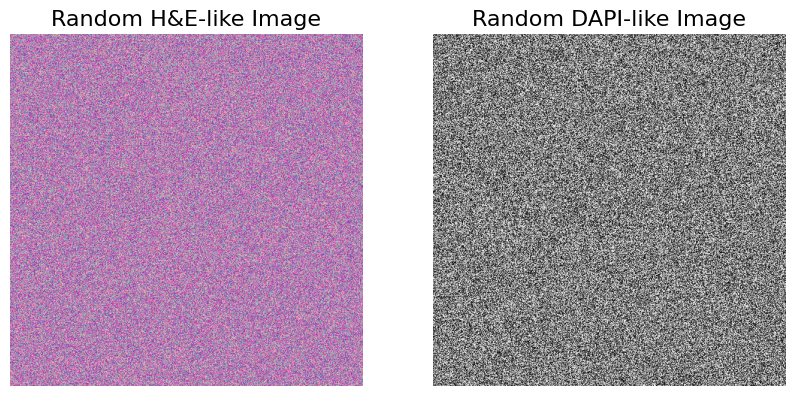

In [7]:
# Display the generated images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(he_image)
plt.title("Random H&E-like Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(dapi_image, cmap='gray')
plt.title("Random DAPI-like Image")
plt.axis('off')

plt.show()

### Generate `AnnData` object containing single-cell transcriptomic data

In this step we generate an `AnnData` object with the spatial coordinates saved in `.obsm["spatial"]` and a `numpy` Array with the boundaries of the cells.

The segmentation mask is a 2D array with 0 as background value and integer values ascending from 1 for each individual cell. The `seg_mask_value` variable is a list of these integer values. It serves as a link between the names of the cells (found in `adata.obs_names`) and their corresponding numbers in the segmentation mask. So, if you have a cell named "Cell_A" in adata.obs_names, seg_mask_value will tell you which number in the segmentation mask represents "Cell_A".

In [8]:
# generate random anndata
adata = generate_dummy_anndata(width=width, height=height, n_cells=n_cells, num_genes=num_genes, pixel_size=pixel_size)

In [9]:
print(adata)

AnnData object with n_obs × n_vars = 10 × 20
    obs: 'cell_type', 'batch'
    obsm: 'spatial'


In [10]:
# generate random boundaries mask
cellular_boundaries_array, seg_mask_value = generate_cellular_boundaries_array(
    width=width, height=height,
    cell_positions=adata.obsm["spatial"],
    pixel_size=pixel_size, cell_size=cell_size)

In [11]:
print(type(cellular_boundaries_array))
print(cellular_boundaries_array)
print(type(seg_mask_value))
print(seg_mask_value)

<class 'numpy.ndarray'>
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
<class 'list'>
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


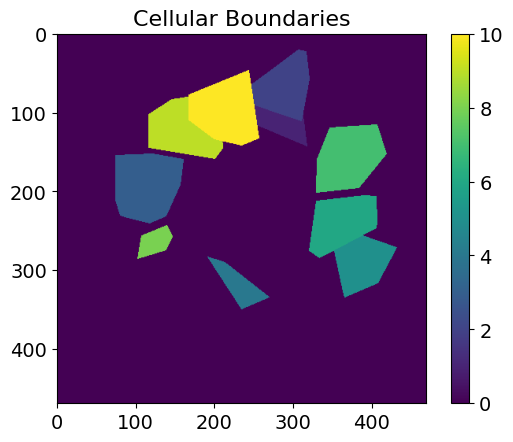

In [12]:
# Plot the boundaries
plt.imshow(cellular_boundaries_array, cmap='viridis')
plt.title("Cellular Boundaries")
plt.colorbar()
plt.show()

### Let's also generate example annotations and regions

Here, we setup the annotations from scratch as `geopandas.DataFrame`. Alternatively, they can be imported from QuPath as `geojson` files as explained in the [annotations notebook](../01_demo_analysis/03_InSituPy_demo_annotations.ipynb).

In [13]:
# generate random annotations and regions
gdf_annotations = generate_random_geometries(num_polygons=5, x_size=height, y_size=width, pixel_size=pixel_size, mode="annotation")
gdf_regions = generate_random_geometries(num_polygons=5, x_size=height, y_size=width, pixel_size=pixel_size, mode="region")

In [14]:
print(type(gdf_annotations))
print(gdf_annotations)
print(type(gdf_regions))
print(gdf_regions)

<class 'geopandas.geodataframe.GeoDataFrame'>
                                            geometry  \
0  POLYGON ((41.404 47.469, 70.341 47.469, 70.341...   
1  POLYGON ((0.986 15.827, 26.795 15.827, 26.795 ...   
2  POLYGON ((84.257 20.987, 106.583 20.987, 106.5...   
3  POLYGON ((1.311 81.665, 26.358 81.665, 26.358 ...   
4  POLYGON ((2.992 42.855, 26.582 42.855, 26.582 ...   

                                     id         name  
0  40bf80c1-7a73-4233-9035-400b03dedc20  annotation1  
1  56edc3b6-be78-4071-b36d-783893a19454  annotation1  
2  a56d067b-66c9-4ff7-8683-a1887eb8ed31  annotation2  
3  de4435ca-d1fb-4b51-9dc5-ee740cd2b8d9  annotation2  
4  ae4eefdc-3229-4c5d-99af-ac6e4c87f93f  annotation2  
<class 'geopandas.geodataframe.GeoDataFrame'>
                                            geometry  \
0  POLYGON ((55.145 7.467, 90.792 7.467, 90.792 4...   
1  POLYGON ((13.445 4.137, 33.525 4.137, 33.525 2...   
2  POLYGON ((74.288 76.731, 103.811 76.731, 103.8...   
3  POLYGON ((36.3

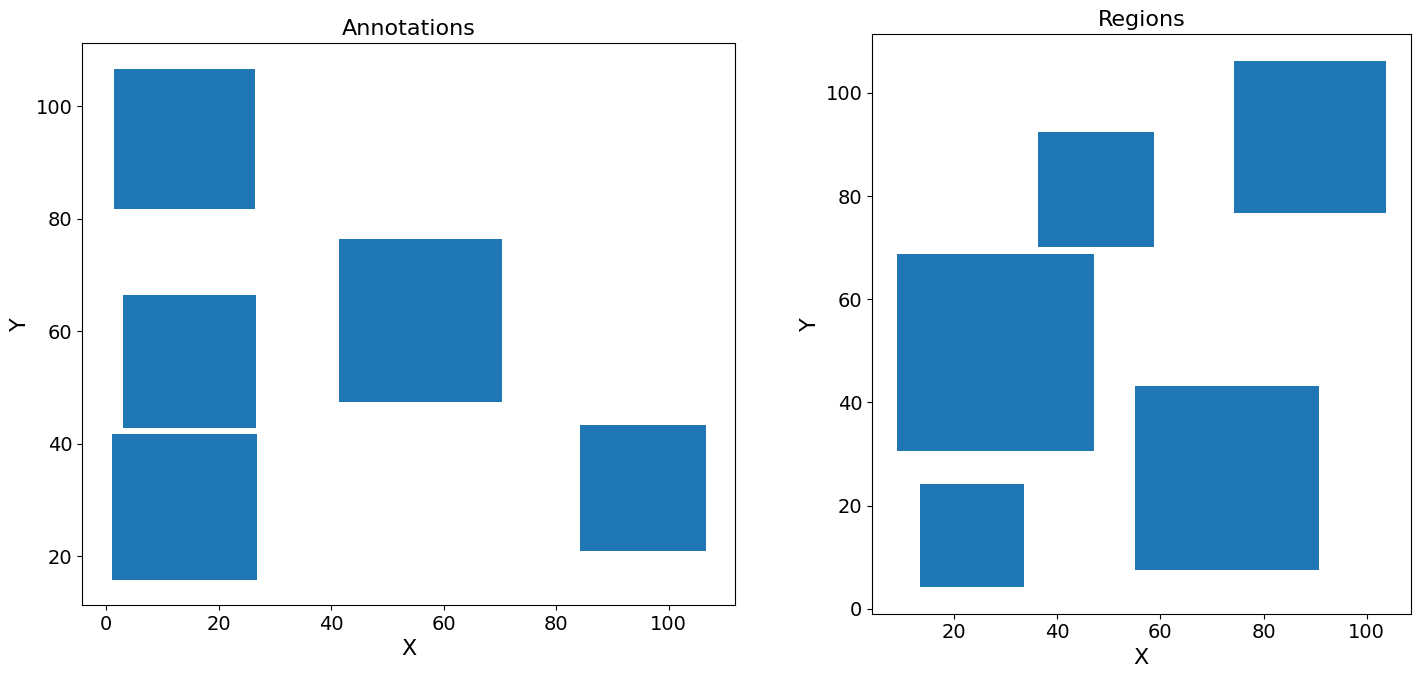

In [15]:
# Plot the annotations and regions
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 7))

gdf_annotations.plot(ax=axes[0])
axes[0].set_title("Annotations")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

gdf_regions.plot(ax=axes[1])
axes[1].set_title("Regions")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")

plt.tight_layout()
plt.show()

## Finally we create an `InSituData` object with all the modalities we have generated before

In [19]:
xd = InSituData(
    path=Path("dummy_path"),
    metadata={
        "method": "Xenium"
              },
    slide_id="slide",
    sample_id="sample_1",
    )

In [20]:
xd

InSituData
Method:		Xenium
Slide ID:	slide
Sample ID:	sample_1
Path:		C:\Users\ge37voy\Github\InSituPy\docs\source\tutorials\04_data_import\dummy_path


No modalities loaded.

Then we add the data in the correct format. A `CellData` object consists of (i) the transcriptomic data as `AnnData` object and (ii) the cellular and/or nuclear boundaries as `BoundariesData` object.

In [22]:
# set up the boundaries data object
bd = BoundariesData(cell_names=adata.obs_names.astype(str), seg_mask_value=seg_mask_value)
bd.add_boundaries(cell_boundaries=cellular_boundaries_array, pixel_size=pixel_size)

# set up the object for the cellular data based on the anndata object and the boundaries object
cd = CellData(matrix=adata, boundaries=bd)
xd.cells.add_celldata(cd=cd, key="main", is_main=True)

In [23]:
xd

InSituData
Method:		Xenium
Slide ID:	slide
Sample ID:	sample_1
Path:		C:\Users\ge37voy\Github\InSituPy\docs\source\tutorials\04_data_import\dummy_path

    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 10 × 20
               obs: 'cell_type', 'batch'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells

In [24]:
xd.cells.matrix

AnnData object with n_obs × n_vars = 10 × 20
    obs: 'cell_type', 'batch'
    obsm: 'spatial'

In [25]:
xd.cells.boundaries

BoundariesData object with 2 entries:
    cells

In [26]:
xd.cells.boundaries["cells"]

dask.array<array, shape=(470, 470), dtype=uint8, chunksize=(470, 470), chunktype=numpy.ndarray>

Images are stored in an `ImageData` object:

In [27]:
# add an empty ImageData object and add the generated images
xd.images.add_image(image=he_image, name="H&E", axes="YXS", pixel_size=pixel_size, ome_meta={'PhysicalSizeX': pixel_size})
xd.images.add_image(image=dapi_image, name="nuclei", axes="YX", pixel_size=pixel_size, ome_meta={'PhysicalSizeX': pixel_size})

... and annotations and regions as `AnnotationsData` or `RegionsData`, respectively.

In [28]:
# add the annotations and regions data
xd.annotations.add_data(gdf_annotations, key="example_annotation", scale_factor=1)
xd.regions.add_data(gdf_regions, key="example_regions", scale_factor=1)

In [29]:
xd

InSituData
Method:		Xenium
Slide ID:	slide
Sample ID:	sample_1
Path:		C:\Users\ge37voy\Github\InSituPy\docs\source\tutorials\04_data_import\dummy_path

    ➤ images
       H&E:	(470, 470, 3)
       nuclei:	(470, 470)
    ➤ cells
       MultiCellData with main layer 'main'
           matrix
               AnnData object with n_obs × n_vars = 10 × 20
               obs: 'cell_type', 'batch'
               obsm: 'spatial'
           boundaries
               BoundariesData object with 2 entries:
                   cells
    ➤ annotations
       example_annotation:	5 annotations, 2 classes ('annotation1', 'annotation2') 
    ➤ regions
       example_regions:	5 regions, 5 classes ('0', '1', '2', '3', '4') 

## Save the data into an `InSituPy` project

In [30]:
savepath = 'out/dummy_data'
xd.saveas(savepath, overwrite=True)

Saving data to out\dummy_data
Saved.


## Reload data

In [31]:
xd = InSituData.read(savepath)
xd.load_all()

## Visualize the data using the `napari` viewer

In [32]:
xd.show()